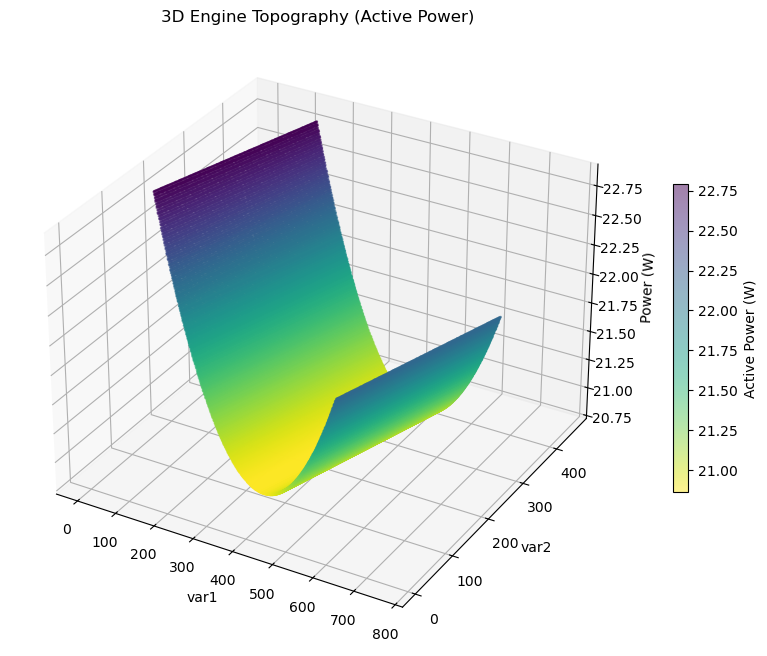

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv('Datos/Originales/Datos/02_Reinforcement_learning/Datos_v1.csv')

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

grafico = ax.scatter(df['var1'], df['var2'], df['w'], 
                     c=df['w'], cmap='viridis_r', s=1, alpha=0.5)

ax.set_title('3D Engine Topography (Active Power)')
ax.set_xlabel('var1')
ax.set_ylabel('var2')
ax.set_zlabel('Power (W)')

fig.colorbar(grafico, label='Active Power (W)', shrink=0.5)

plt.show()

c:\Users\danie\anaconda3\envs\reto11\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\danie\anaconda3\envs\reto11\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Starting Grid Search with 27 combinations...


Evaluating Models: 100%|██████████| 27/27 [2:45:41<00:00, 368.19s/model]  


Best path length: 530 steps
Best Hyperparameters: {'alpha': 0.3, 'gamma': 0.99, 'epsilon_decay': 0.99}

Top 3 configurations:
1. Steps: 530 | {'alpha': 0.3, 'gamma': 0.99, 'epsilon_decay': 0.99}
2. Steps: 531 | {'alpha': 0.3, 'gamma': 0.99, 'epsilon_decay': 0.995}
3. Steps: 531 | {'alpha': 0.5, 'gamma': 0.995, 'epsilon_decay': 0.98}


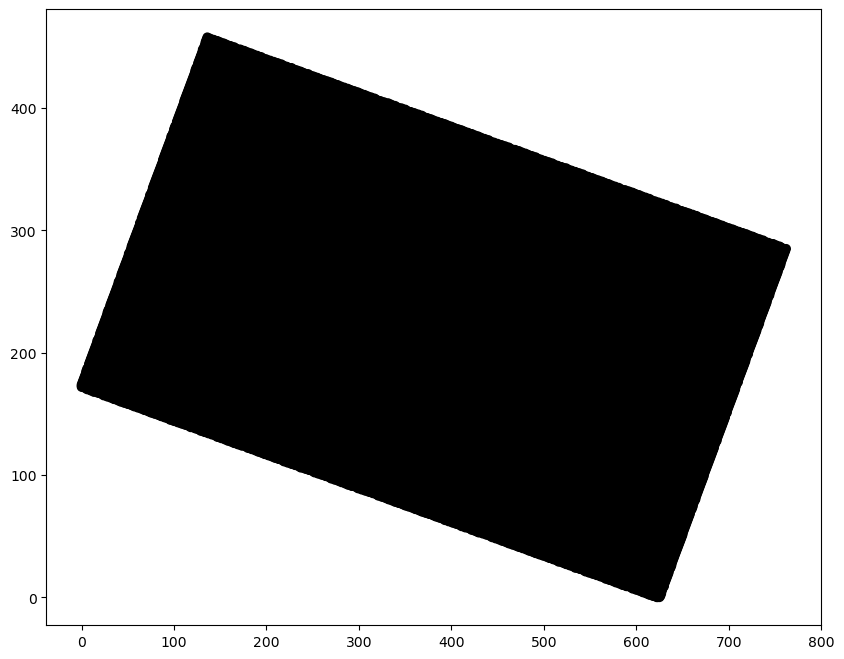

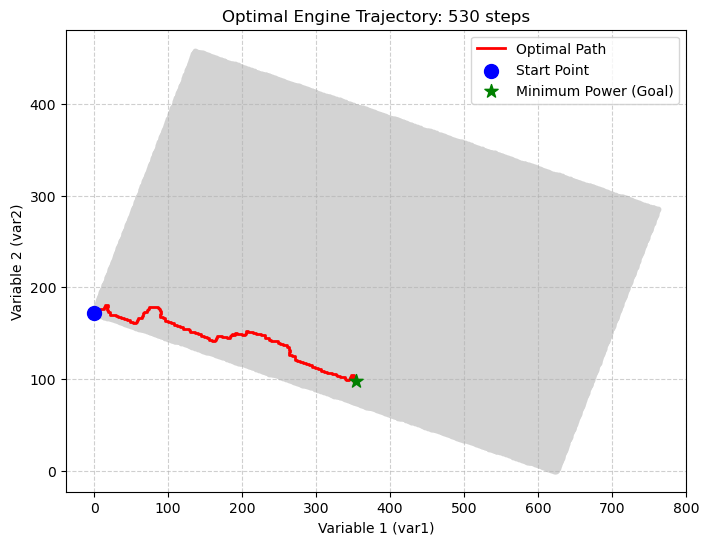

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools
import io
from contextlib import redirect_stdout
from tqdm import tqdm
from env_R11_v1 import motorEnv

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

param_grid = {
    'alpha': [0.3, 0.5, 0.8],            
    'gamma': [0.95, 0.99, 0.995],         
    'epsilon_decay': [0.98, 0.99, 0.995]  
}

episodes = 250
max_steps = 1500
epsilon_min = 0.01

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_path_length = float('inf')
best_params = None
best_q_table = None
all_results = []

with redirect_stdout(io.StringIO()):
    env = motorEnv()
    env.action_space.seed(SEED)

print(f"Starting Grid Search with {len(combinations)} combinations...")

for params in tqdm(combinations, desc="Evaluating Models", unit="model"):
    
    alpha = params['alpha']
    gamma = params['gamma']
    epsilon_decay = params['epsilon_decay']
    epsilon = 1.0
    
    q_table = np.zeros([env.num_states, env.action_space.n])
    
    with redirect_stdout(io.StringIO()):
        for ep in range(episodes):
            reset_res = env.reset()
            state = reset_res[0] if isinstance(reset_res, tuple) else reset_res
            done = False
            step = 0
            
            while not done and step < max_steps:
                if random.uniform(0, 1) < epsilon:
                    action = env.action_space.sample()
                else:
                    action = np.argmax(q_table[state])
                    
                step_result = env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, _ = step_result
                else:
                    next_state, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated
                
                current_w = env.rot.iloc[state, 2]
                next_w = env.rot.iloc[next_state, 2]
                if reward not in [-100, 1000]:
                    if next_w < current_w: reward += 5
                    elif next_w > current_w: reward -= 5
                        
                old_value = q_table[state, action]
                next_max = np.max(q_table[next_state])
                q_table[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
                
                state = next_state
                step += 1
                
            if epsilon > epsilon_min:
                epsilon *= epsilon_decay
        
        reset_res = env.reset()
        state = reset_res[0] if isinstance(reset_res, tuple) else reset_res
        done = False
        path_length = 0
        
        while not done and path_length < max_steps:
            action = np.argmax(q_table[state])
            step_result = env.step(action)
            if len(step_result) == 4:
                state, reward, done, _ = step_result
            else:
                state, reward, terminated, truncated, _ = step_result
                done = terminated or truncated
            path_length += 1
            
    if path_length < max_steps:
        all_results.append({'params': params, 'steps': path_length})
        
        if path_length < best_path_length:
            best_path_length = path_length
            best_params = params
            best_q_table = np.copy(q_table) 

if best_params:
    print(f"Best path length: {best_path_length} steps")
    print(f"Best Hyperparameters: {best_params}")
    
    print("\nTop 3 configurations:")
    top_3 = sorted(all_results, key=lambda x: x['steps'])[:3]
    for i, res in enumerate(top_3):
        print(f"{i+1}. Steps: {res['steps']} | {res['params']}")
else:
    print("No configuration reached the goal within the allowed steps.")

if best_q_table is not None:
    with redirect_stdout(io.StringIO()):
        reset_res = env.reset()
        state = reset_res[0] if isinstance(reset_res, tuple) else reset_res
        done = False
        opt_v1 = [env.rot.iloc[state, 0]]
        opt_v2 = [env.rot.iloc[state, 1]]

        while not done:
            action = np.argmax(best_q_table[state]) 
            step_result = env.step(action)
            
            if len(step_result) == 4:
                state, reward, done, _ = step_result
            else:
                state, reward, terminated, truncated, _ = step_result
                done = terminated or truncated
                
            opt_v1.append(env.rot.iloc[state, 0])
            opt_v2.append(env.rot.iloc[state, 1])
            
            if len(opt_v1) > max_steps: break

    plt.figure(figsize=(8, 6))
    plt.scatter(env.rot['var1'], env.rot['var2'], c='lightgray', s=10)
    plt.plot(opt_v1, opt_v2, color='red', linewidth=2, label='Optimal Path')
    plt.scatter(opt_v1[0], opt_v2[0], color='blue', s=100, label='Start Point', zorder=5)
    plt.scatter(opt_v1[-1], opt_v2[-1], color='green', s=100, marker='*', label='Minimum Power (Goal)', zorder=5)
    
    plt.title(f'Optimal Engine Trajectory: {best_path_length} steps')
    plt.xlabel('Variable 1 (var1)')
    plt.ylabel('Variable 2 (var2)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

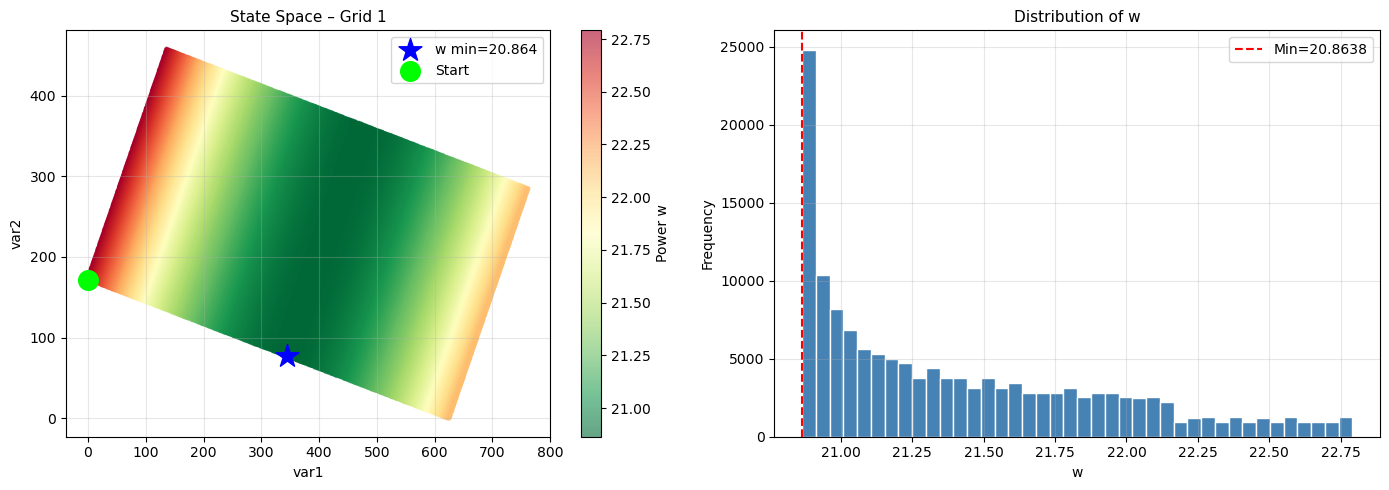

In [ ]:
df_viz    = env.rot.copy()
idx_min   = df_viz['w'].idxmin()
w_min_val = df_viz['w'].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(df_viz['var1'], df_viz['var2'],
                     c=df_viz['w'], cmap='RdYlGn_r', s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='Power w')
axes[0].scatter(df_viz.loc[idx_min, 'var1'], df_viz.loc[idx_min, 'var2'],
                c='blue', s=300, marker='*', zorder=6,
                label=f'w min={w_min_val:.3f}')
axes[0].scatter(df_viz.iloc[0]['var1'], df_viz.iloc[0]['var2'],
                c='lime', s=200, marker='o', zorder=6, label='Start')
axes[0].set_title('State Space – Grid 1', fontsize=11)
axes[0].set_xlabel('var1')
axes[0].set_ylabel('var2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_viz['w'], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(w_min_val, color='red', linestyle='--',
                label=f'Min={w_min_val:.4f}')
axes[1].set_title('Distribution of w', fontsize=11)
axes[1].set_xlabel('w')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


reward: 1000


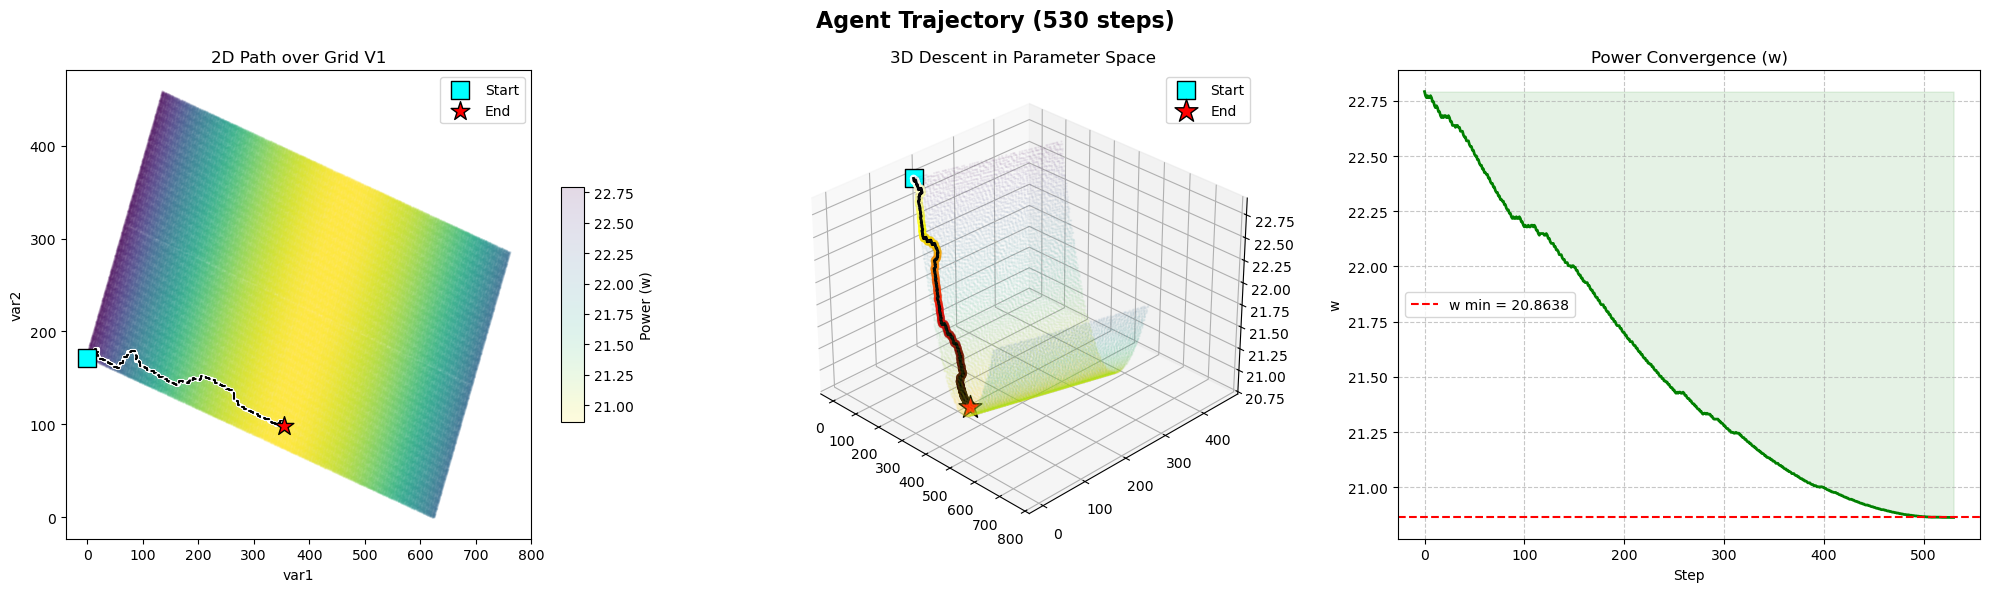

In [ ]:
with redirect_stdout(io.StringIO()):
    reset_res = env.reset()
    state     = reset_res[0] if isinstance(reset_res, tuple) else reset_res

path_var1 = [env.rot.iloc[state]['var1']]
path_var2 = [env.rot.iloc[state]['var2']]
path_w    = [env.rot.iloc[state]['w']]
done      = False

while not done and len(path_w) <= max_steps:
    action      = np.argmax(best_q_table[state])
    step_result = env.step(action)
    if len(step_result) == 4:
        state, reward, done, _ = step_result
    else:
        state, reward, terminated, truncated, _ = step_result
        done = terminated or truncated
    path_var1.append(env.rot.iloc[state]['var1'])
    path_var2.append(env.rot.iloc[state]['var2'])
    path_w.append(env.rot.iloc[state]['w'])

all_var1 = env.rot['var1'].values
all_var2 = env.rot['var2'].values
all_w    = env.rot['w'].values

fig = plt.figure(figsize=(20, 6))
fig.suptitle(f'Agent Trajectory ({best_path_length} steps)',
             fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(1, 3, 1)
map2d = ax1.scatter(all_var1, all_var2, c=all_w,
                    cmap='viridis_r', s=1, alpha=0.15)
ax1.plot(path_var1, path_var2,
         color='white', linewidth=3, zorder=4)
ax1.plot(path_var1, path_var2,
         color='black', linestyle='--', linewidth=1.5, zorder=5)
ax1.scatter(path_var1[0], path_var2[0],
            color='cyan', edgecolors='black',
            s=150, marker='s', label='Start', zorder=6)
ax1.scatter(path_var1[-1], path_var2[-1],
            color='red', edgecolors='black',
            s=200, marker='*', label='End', zorder=6)
ax1.set_title('2D Path over Grid V1')
ax1.set_xlabel('var1')
ax1.set_ylabel('var2')
ax1.legend()
fig.colorbar(map2d, ax=ax1, shrink=0.5, aspect=10, label='Power (w)')

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.scatter(all_var1[::5], all_var2[::5], all_w[::5],
            c=all_w[::5], cmap='viridis_r', s=0.5, alpha=0.05)
ax2.plot(path_var1, path_var2, path_w,
         color='black', linewidth=2, zorder=4)
ax2.scatter(path_var1, path_var2, path_w,
            c=path_w, cmap='hot',
            marker='o', s=30, edgecolors='none', zorder=5)
ax2.scatter(path_var1[0], path_var2[0], path_w[0],
            color='cyan', s=150, marker='s',
            edgecolors='black', label='Start')
ax2.scatter(path_var1[-1], path_var2[-1], path_w[-1],
            color='red', s=300, marker='*',
            edgecolors='black', label='End')
ax2.set_title('3D Descent in Parameter Space')
ax2.view_init(elev=30, azim=-45)
ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(path_w, color='green', linewidth=2)
ax3.fill_between(range(len(path_w)), path_w, max(path_w),
                 color='green', alpha=0.1)
ax3.axhline(env.rot['w'].min(), color='red', linestyle='--',
            label=f'w min = {env.rot["w"].min():.4f}')
ax3.set_title('Power Convergence (w)')
ax3.set_xlabel('Step')
ax3.set_ylabel('w')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import io
from contextlib import redirect_stdout

if 'best_q_table' in locals() and best_q_table is not None:
    
    with redirect_stdout(io.StringIO()):
        reset_res = env.reset()
        state = reset_res[0] if isinstance(reset_res, tuple) else reset_res
        done = False
        
        paso_list = [0]
        var1_list = [env.rot.iloc[state, 0]]
        var2_list = [env.rot.iloc[state, 1]]
        w_list = [env.rot.iloc[state, 2]]
        
        paso_actual = 1
        
        while not done:
            max_val = np.max(best_q_table[state])
            best_actions = np.where(best_q_table[state] == max_val)[0]
            action = np.random.choice(best_actions)
            
            step_result = env.step(action)
            
            if len(step_result) == 4:
                next_state, reward, done, _ = step_result
            else:
                next_state, reward, terminated, truncated, _ = step_result
                done = terminated or truncated
            
            paso_list.append(paso_actual)
            var1_list.append(env.rot.iloc[next_state, 0])
            var2_list.append(env.rot.iloc[next_state, 1])
            w_list.append(env.rot.iloc[next_state, 2])
            
            state = next_state
            paso_actual += 1
            
            if paso_actual > max_steps:
                break

    df_optimal_path = pd.DataFrame({
        'paso': paso_list,
        'var1': var1_list,
        'var2': var2_list,
        'w': w_list
    })
    
    csv_filename = 'Datos/Transformados/RL/ruta_optima_v1.csv'
    df_optimal_path.to_csv(csv_filename, index=False)

    display(df_optimal_path)

,paso,var1,var2,w
0,0,0.0,172.0,22.791552
1,1,1.0,172.0,22.773219
2,2,2.0,172.0,22.764086
3,3,2.0,173.0,22.773219
4,4,3.0,173.0,22.764086
...,...,...,...,...
526,526,350.0,98.0,20.864005
527,527,351.0,98.0,20.863847
528,528,352.0,98.0,20.863847
529,529,353.0,98.0,20.863776
